2. MACHINE LEARNING FOR REGRESSION

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


2.2 DATA PREPARATION

In [5]:
# data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [6]:
# !wget $data 

In [7]:
df = pd.read_csv('data.csv')
len(df)

11914

In [8]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [9]:
df.columns.str.lower()

Index(['make', 'model', 'year', 'engine fuel type', 'engine hp',
       'engine cylinders', 'transmission type', 'driven_wheels',
       'number of doors', 'market category', 'vehicle size', 'vehicle style',
       'highway mpg', 'city mpg', 'popularity', 'msrp'],
      dtype='str')

In [10]:
df.columns.str.lower().str.replace(' ', '_')

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [11]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [12]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [13]:
df.dtypes[df.dtypes == 'str']

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [14]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [15]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [16]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


2.3: EXPLORATORY DATA ANALYSIS


In [17]:

for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

<Axes: xlabel='msrp', ylabel='Count'>

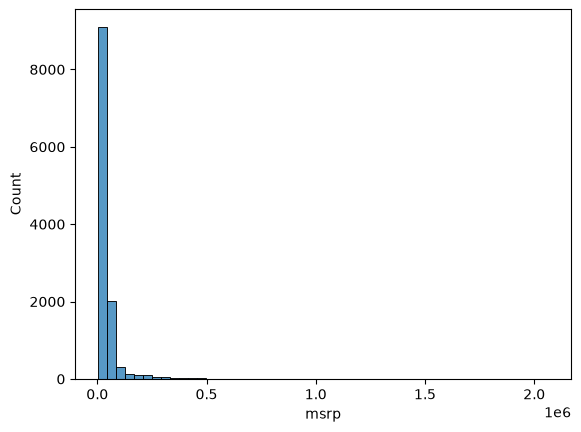

In [18]:
# distribution of prices
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

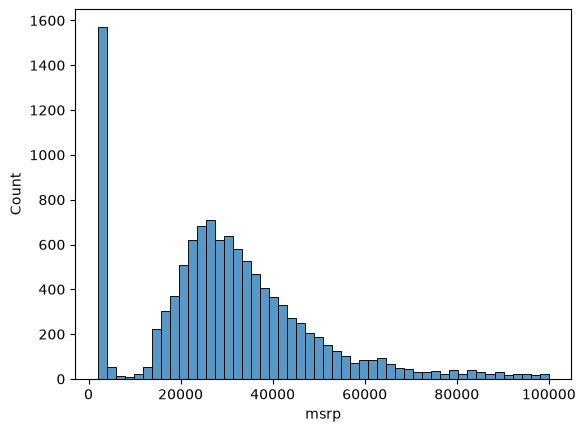

In [19]:
# prices below 100000
sns.histplot(df.msrp[df.msrp<100000],bins=50)

In [20]:
np.log([0+1,1+1,10+1,1000+1,100000+1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [21]:
np.log1p([0,1,10,1000,100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [22]:
price_logs=np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

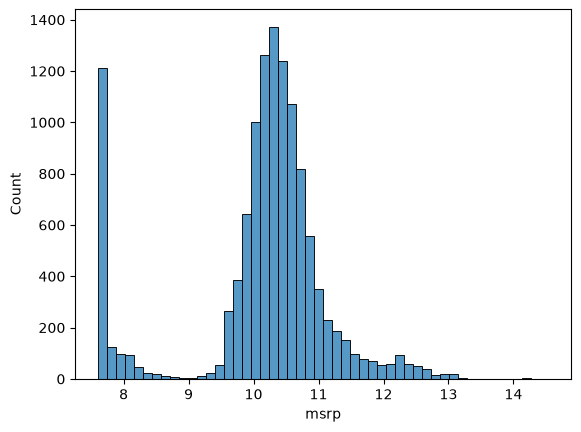

In [23]:
# normal distribution
sns.histplot(price_logs,bins=50)

In [24]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

2.4 SETTING UP THE VALIDATION FRAMEWORK

In [25]:

n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train= n- n_val-n_test

In [26]:
n_val,n_test,n_train

(2382, 2382, 7150)

In [27]:
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


In [28]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val+n_test]
df_train = df.iloc[n_val+n_test:]

In [29]:
idx = np.arange(n)
np.random.shuffle(idx)

In [30]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [31]:
np.random.seed(2)

idx = np.arange(n)
np.random.shuffle(idx)

In [32]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [33]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [34]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [35]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,acura,integra,2001,regular_unleaded,140.0,4.0,automatic,front_wheel_drive,2.0,"hatchback,luxury",compact,2dr_hatchback,28,21,204,21850
1,scion,xa,2005,regular_unleaded,108.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,35,27,105,13330
2,acura,nsx,2005,regular_unleaded,252.0,6.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",compact,coupe,22,16,204,89000
3,ford,f-150,2016,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,17,5657,62310
4,suzuki,x-90,1996,regular_unleaded,95.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,2dr_suv,26,22,481,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,cadillac,escalade,2016,premium_unleaded_(recommended),420.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,performance",large,4dr_suv,22,15,1624,89350
7146,mazda,tribute,2009,regular_unleaded,240.0,6.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,24,17,586,24805
7147,ford,expedition,2017,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,NaN,large,4dr_suv,20,15,5657,48936
7148,ford,e-150,1997,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,passenger_van,17,12,5657,2000


In [36]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [37]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,acura,integra,2001,regular_unleaded,140.0,4.0,automatic,front_wheel_drive,2.0,"hatchback,luxury",compact,2dr_hatchback,28,21,204
1,scion,xa,2005,regular_unleaded,108.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,35,27,105
2,acura,nsx,2005,regular_unleaded,252.0,6.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",compact,coupe,22,16,204
3,ford,f-150,2016,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,17,5657
4,suzuki,x-90,1996,regular_unleaded,95.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,2dr_suv,26,22,481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,cadillac,escalade,2016,premium_unleaded_(recommended),420.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,performance",large,4dr_suv,22,15,1624
7146,mazda,tribute,2009,regular_unleaded,240.0,6.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,24,17,586
7147,ford,expedition,2017,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,NaN,large,4dr_suv,20,15,5657
7148,ford,e-150,1997,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,passenger_van,17,12,5657


2.5 LINEAR REGRESSION SIMPLE

In [38]:
df_train.iloc[10]

make                           hyundai
model                   santa_fe_sport
year                              2015
engine_fuel_type      regular_unleaded
engine_hp                        190.0
engine_cylinders                   4.0
transmission_type            automatic
driven_wheels        front_wheel_drive
number_of_doors                    4.0
market_category              crossover
vehicle_size                   midsize
vehicle_style                  4dr_suv
highway_mpg                         27
city_mpg                            20
popularity                        1439
Name: 10, dtype: object

In [39]:
xi=[453,11,86]

In [40]:
w0=7.17
w=[0.01,0.04,0.002]

In [41]:
def linear_regression(xi):
    n=len(xi)
    pred=w0
    for j in range (n):
        pred= pred + w[j] * xi[j]
    return pred

In [42]:
linear_regression(xi)

12.312

In [43]:
# the price of the  car is about $222347
np.expm1(12.312).item()

222347.2221101062

In [44]:
np.log1p(222347.2221101062)

np.float64(12.312)

2.6:LINEAR REGRESSION VECTOR FORM

In [45]:
def dot(xi,w):
    n= len(xi)

    res=0.0

    for j in range (n):
        res= res +  xi[j] *w[j] 

    return res




In [46]:
def linear_regression (xi):
    return w0 + dot(xi, w)

In [47]:
w_new = [w0] + w

In [48]:
def linear_regression (xi):
    xi=[1] + xi
    return dot(xi,w_new)

In [49]:
linear_regression(xi)

12.312

Linear regression for all cars

In [50]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]
x= [x1,x2,x10]
x=np.array(x)
x

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [51]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [52]:
def linear_regression(xi):
    return x.dot(w_new)

In [53]:
linear_regression(x)

array([12.38 , 13.552, 12.312])

2.7 TRAINING A LINEAR REGRESSION MODEL

In [54]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [55]:
XTX=X.T.dot(X)

In [56]:
XTX_inv=np.linalg.inv(XTX)

In [57]:
XTX.dot(XTX_inv).round(1)

array([[ 1.,  0.,  0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [58]:
# target vector y
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [59]:
w_full = XTX_inv.dot(X.T).dot(y)

In [60]:
ones= np.ones(X.shape[0])
x= np.column_stack([ones,X])
XTX=x.T.dot(x)
XTX_inv=np.linalg.inv(XTX)
w_full = XTX_inv.dot(x.T).dot(y)

In [61]:
w0=w_full[0]
w=w_full[1:]

In [62]:
def linear_regression(X, y):
    ones= np.ones(X.shape[0])
    X= np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX_inv=np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]


2.8: BASELINE-MODEL

In [63]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [64]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']
df_train[base]


,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,140.0,4.0,28,21,204
1,108.0,4.0,35,27,105
2,252.0,6.0,22,16,204
3,365.0,6.0,23,17,5657
4,95.0,4.0,26,22,481
...,...,...,...,...,...
7145,420.0,8.0,22,15,1624
7146,240.0,6.0,24,17,586
7147,365.0,6.0,20,15,5657
7148,200.0,6.0,17,12,5657


In [65]:
X_train = df_train[base].values

In [66]:
df_train[base].isnull().sum()

engine_hp           42
engine_cylinders    15
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [67]:
X_train = df_train[base].fillna(0).values

In [68]:
y_train

array([ 9.99200197,  9.49784743, 11.39640288, ..., 10.79828904,
        7.60140233,  7.60140233], shape=(7150,))

In [69]:
w0 , w =linear_regression(X_train, y_train)

In [70]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

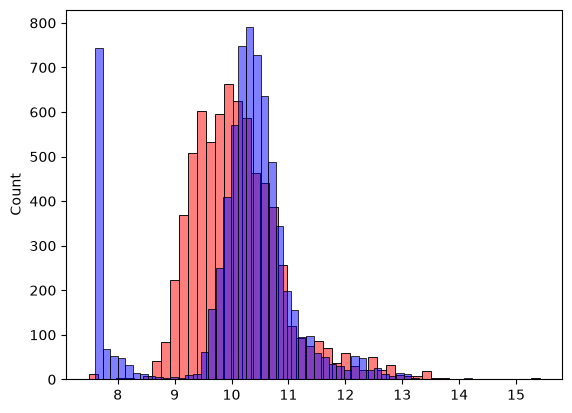

In [71]:
sns.histplot(y_pred,color='red',alpha=0.5,bins=50)
sns.histplot(y_train,color='blue',alpha=0.5,bins=50)

2.9 RMSE

In [72]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [73]:
rmse(y_train, y_pred).item()

0.753985214312505

2.10: VALIDATING THE MODEL

In [74]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']
X_train = df_train[base].fillna(0).values
w0 , w =linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)

In [75]:
def prepare_X(df):
    df_num= df[base]
    df_num = df_num.fillna(0)
    X=df_num.values
    return X

In [76]:
X_train = prepare_X(df_train)
w0, w = linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).item()

0.7430848543890894

2.11: FEATURE ENGINEERING

In [77]:
df_train.year.max().item()

2017

In [78]:
2017-df_train.year


0       16
1       12
2       12
3        1
4       21
        ..
7145     1
7146     8
7147     0
7148    20
7149    20
Name: year, Length: 7150, dtype: int64

In [79]:
def prepare_X(df):
    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [80]:
def prepare_X(df):
    df = df.copy()

    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [81]:
X_train = prepare_X(df_train)
w0, w = linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).item()

0.5156330309823504

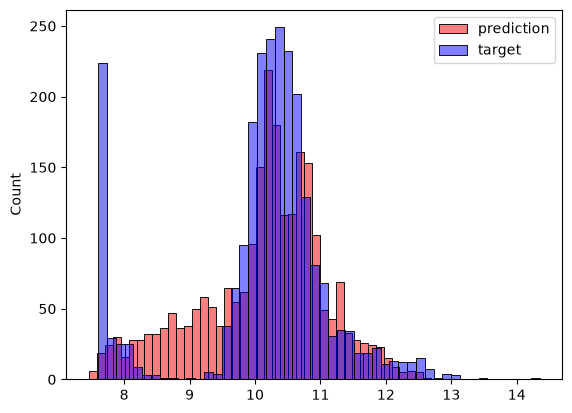

In [82]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

2.12: CATEGORICAL VARIABLES


In [83]:
df_train.number_of_doors ==2

0        True
1       False
2        True
3       False
4        True
        ...  
7145    False
7146    False
7147    False
7148    False
7149    False
Name: number_of_doors, Length: 7150, dtype: bool

In [84]:
for v in [2,3,4]:
    df_train['num_doors_%s'% v] =(df_train.number_of_doors==v).astype(int)

In [85]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [86]:
X_train = prepare_X(df_train)
w0, w = linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).item()

0.5108189077484684

ADDING MAKES

In [87]:
makes=list(df.make.value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [88]:
for v in makes:
    df_train['make_%s' % v] = (df_train.make == v).astype(int)
    

In [89]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [90]:
X_train = prepare_X(df_train)
w0, w = linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).item()

0.5017087532688294

In [91]:
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]



In [92]:
categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [93]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [94]:
X_train = prepare_X(df_train)
w0, w = linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).item()

98.77346303709493

2.13: REGULARIZATION

In [95]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.0001],
]
X= np.array(X)
X

array([[4.    , 4.    , 4.    ],
       [3.    , 5.    , 5.    ],
       [5.    , 1.    , 1.    ],
       [5.    , 4.    , 4.    ],
       [7.    , 5.    , 5.    ],
       [4.    , 5.    , 5.0001]])

In [96]:
XTX=X.T.dot(X)

In [97]:
np.linalg.inv(XTX)

array([[ 4.12730055e-02, -6.11682842e+02,  6.11637591e+02],
       [-6.11682842e+02,  1.39187393e+08, -1.39186120e+08],
       [ 6.11637591e+02, -1.39186120e+08,  1.39184847e+08]])

In [98]:
XTX = [
    [1, 2, 2],
    [2, 1, 1],
    [2, 1, 1],
]

In [99]:
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1],
]

In [100]:
XTX + np.eye(3)

array([[2.       , 2.       , 2.       ],
       [2.       , 2.       , 1.0000001],
       [2.       , 1.0000001, 2.       ]])

In [101]:
XTX = XTX + 0.01 * np.eye(3)

In [104]:
def linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [106]:
X_train = prepare_X(df_train)
w0, w = linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).item()

0.4544793923094481

2.14: TUNING THE MODEL

In [107]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score)

0.0 2359188575698763.0 98.77346303709493
1e-05 8.78340018507436 0.4544629999242782
0.0001 6.326448550901588 0.4544631125841642
0.001 6.335579560330524 0.4544643420598313
0.1 6.116868987454534 0.45482256103339336
1 5.357593525132616 0.45947425543879084
10 4.241600929898787 0.4758770576010191


In [108]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.4544643420598313)

2.15: USING THE MODEL

In [109]:
df_full_train = pd.concat([df_train, df_val])

In [110]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,...,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4,make_chevrolet,make_ford,make_volkswagen,make_toyota,make_dodge
0,acura,integra,2001,regular_unleaded,140.0,4.0,automatic,front_wheel_drive,2.0,"hatchback,luxury",...,21,204,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,scion,xa,2005,regular_unleaded,108.0,4.0,automatic,front_wheel_drive,4.0,hatchback,...,27,105,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,acura,nsx,2005,regular_unleaded,252.0,6.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",...,16,204,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ford,f-150,2016,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,NaN,...,17,5657,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,suzuki,x-90,1996,regular_unleaded,95.0,4.0,manual,rear_wheel_drive,2.0,NaN,...,22,481,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,mazda,3,2016,regular_unleaded,184.0,4.0,automatic,front_wheel_drive,4.0,performance,...,28,586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2378,honda,cr-z,2015,regular_unleaded,130.0,4.0,automatic,front_wheel_drive,2.0,"hatchback,hybrid",...,36,2202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2379,subaru,baja,2005,premium_unleaded_(required),210.0,4.0,automatic,all_wheel_drive,4.0,crossover,...,16,640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2380,ford,flex,2016,premium_unleaded_(recommended),365.0,6.0,automatic,all_wheel_drive,4.0,crossover,...,15,5657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
df_full_train = df_full_train.reset_index(drop=True)

In [113]:
X_full_train = prepare_X(df_full_train)

In [114]:
y_full_train = np.concatenate([y_train, y_val])

In [115]:
y_full_train = np.concatenate([y_train, y_val])

In [116]:
w0, w = linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [ ]:
# Checking the model on test data
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.4612802091137638)

In [118]:
# predicting the price of the car
car = df_test.iloc[20].to_dict()
car

{'make': 'volkswagen',
 'model': 'golf_gti',
 'year': 2017,
 'engine_fuel_type': 'premium_unleaded_(recommended)',
 'engine_hp': 220.0,
 'engine_cylinders': 4.0,
 'transmission_type': 'automated_manual',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': 'hatchback,performance',
 'vehicle_size': 'compact',
 'vehicle_style': '4dr_hatchback',
 'highway_mpg': 32,
 'city_mpg': 24,
 'popularity': 873}

In [119]:
df_small = pd.DataFrame([car])
X_small = prepare_X(df_small)

In [120]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.734648266894476)

In [ ]:
# predicted price of the car
np.expm1(y_pred)

np.float64(45918.643473959266)

In [ ]:
# actual price of the car
np.expm1(y_test[20])

np.float64(31989.999999999996)